# 1.4.4 Smoothing Images

## Kernel Convolution

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [2]:
l=1
kernel = np.array([[0,-1,0],[-1,4,-1],[0,-1,0]],np.float32)

In [3]:
kernel

array([[ 0., -1.,  0.],
       [-1.,  4., -1.],
       [ 0., -1.,  0.]], dtype=float32)

In [4]:
img = np.random.randint(10, size=(12,12))
#img = np.ones((10,10),np.float32)

In [5]:
img

array([[2, 8, 4, 8, 5, 7, 4, 0, 4, 1, 9, 8],
       [1, 2, 7, 4, 8, 4, 9, 0, 6, 9, 5, 7],
       [3, 7, 7, 6, 1, 1, 6, 5, 6, 9, 1, 5],
       [1, 2, 4, 0, 7, 3, 7, 0, 2, 6, 2, 5],
       [4, 9, 5, 8, 8, 2, 2, 3, 5, 4, 6, 3],
       [5, 2, 2, 9, 4, 1, 8, 0, 1, 5, 4, 6],
       [3, 9, 3, 4, 0, 1, 7, 9, 4, 0, 8, 3],
       [8, 4, 0, 7, 4, 2, 7, 9, 5, 8, 2, 2],
       [9, 3, 5, 7, 4, 9, 8, 7, 6, 8, 8, 9],
       [7, 0, 4, 7, 7, 0, 6, 8, 9, 0, 4, 0],
       [3, 3, 9, 8, 7, 8, 3, 4, 9, 5, 8, 0],
       [5, 1, 0, 9, 3, 5, 9, 5, 8, 6, 5, 4]])

In [6]:
h,w=img.shape

In [7]:
print(h,w)

12 12


In [8]:
#[*range(-2,3)]

In [10]:
dst = np.zeros((h,w),dtype=int)

In [11]:
for i in range(l,h-l):
    for j in range(l,w-l):
        t=0
        for p in range(-l,l+1):
            for q in range(-l,l+1):
                t += kernel[p+l,q+l]*img[i+p,j+q]
        dst[i,j]=t        

In [12]:
img

array([[2, 8, 4, 8, 5, 7, 4, 0, 4, 1, 9, 8],
       [1, 2, 7, 4, 8, 4, 9, 0, 6, 9, 5, 7],
       [3, 7, 7, 6, 1, 1, 6, 5, 6, 9, 1, 5],
       [1, 2, 4, 0, 7, 3, 7, 0, 2, 6, 2, 5],
       [4, 9, 5, 8, 8, 2, 2, 3, 5, 4, 6, 3],
       [5, 2, 2, 9, 4, 1, 8, 0, 1, 5, 4, 6],
       [3, 9, 3, 4, 0, 1, 7, 9, 4, 0, 8, 3],
       [8, 4, 0, 7, 4, 2, 7, 9, 5, 8, 2, 2],
       [9, 3, 5, 7, 4, 9, 8, 7, 6, 8, 8, 9],
       [7, 0, 4, 7, 7, 0, 6, 8, 9, 0, 4, 0],
       [3, 3, 9, 8, 7, 8, 3, 4, 9, 5, 8, 0],
       [5, 1, 0, 9, 3, 5, 9, 5, 8, 6, 5, 4]])

In [13]:
dst

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0, -15,  11, -13,  18,  -9,  22, -20,   5,  15,  -6,   0],
       [  0,  14,   4,  12, -18, -10,   2,   8,   2,  14, -17,   0],
       [  0, -13,   2, -25,  16,  -5,  17, -17,  -9,   7, -10,   0],
       [  0,  23,  -3,  10,  11,  -6, -12,   5,  10,  -6,  11,   0],
       [  0, -17, -11,  18,  -2, -11,  22, -21, -10,  11,  -9,   0],
       [  0,  24,  -3,  -3, -13,  -6,   3,  16,   1, -25,  23,   0],
       [  0,  -4, -19,  13,   3, -13,   2,   8,  -7,  17, -18,   0],
       [  0,  -6,   6,   5, -11,  22,   3,  -3,  -5,  10,   9,   0],
       [  0, -17,  -5,   2,  10, -30,   5,   6,  13, -26,   0,   0],
       [  0,  -1,  21,   0,   2,  17, -15,  -9,  10,  -3,  18,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0]])

In [14]:
img = cv2.imread('lena.png', 0)

In [15]:
h,w=img.shape

In [16]:
dst = np.zeros((h-2*l,w-2*l),np.uint8)

In [17]:
for i in range(l,h-l):
    for j in range(l,w-l):
        t=0
        for p in range(-l,l+1):
            for q in range(-l,l+1):
                t += kernel[p+l,q+l]*img[i+p,j+q]
        dst[i-l,j-l]=t 

In [18]:
cv2.imshow('img',img)
cv2.imshow('dst',dst)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [48]:
img1 = cv2.cvtColor(img,cv2.COLOR_BGR2BGRA)


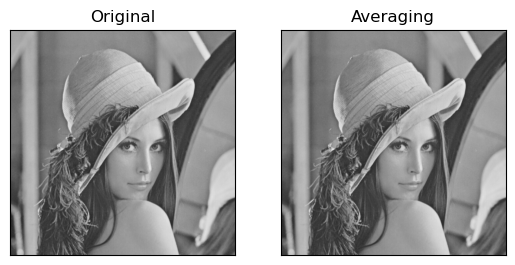

In [50]:
kernel = np.ones((5,5),np.float32)/25
blur = cv2.GaussianBlur(img1,(5,5),0)
#dst = cv2.filter2D(img,-1,kernel)
median = cv2.medianBlur(img1,5)#sorting의 중앙값
plt.subplot(121),plt.imshow(img1),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(img1),plt.title('Averaging')
plt.xticks([]), plt.yticks([])
plt.show()